**Big Data Project**


**Authors:** Nuria, Abjana, & Carter

# Predicting Future Anonymized Numeric Target Values Across Multiple Time-Series Entities and Forecast Horizons Using Supervised Machine Learning.

1. Install Libraries and Load Datasets (already split into test and train):

In [ ]:
# STEP 1 (new) — Load data directly in float32 with memory optimization

from google.colab import drive
import os
import gc
import pandas as pd
import numpy as np

drive.mount('/content/drive')

train_path = "/content/drive/MyDrive/College Class Folder/College Year 4/Spring Semester/Big Data/Big Data Project/Hedge Fund Data Set/train.parquet"
test_path  = "/content/drive/MyDrive/College Class Folder/College Year 4/Spring Semester/Big Data/Big Data Project/Hedge Fund Data Set/test.parquet"

# Load with optimized dtypes from the start
train_df = pd.read_parquet(train_path)
test_df  = pd.read_parquet(test_path)

# Immediately downcast everything to save RAM
for col in train_df.columns:
    if train_df[col].dtype == "float64":
        train_df[col] = train_df[col].astype("float32")
    elif train_df[col].dtype == "int64":
        train_df[col] = train_df[col].astype("int32")

for col in test_df.columns:
    if test_df[col].dtype == "float64":
        test_df[col] = test_df[col].astype("float32")
    elif test_df[col].dtype == "int64":
        test_df[col] = test_df[col].astype("int32")

gc.collect()

print("train_df shape:", train_df.shape)
print("test_df shape: ", test_df.shape)
print(f"train_df memory: {train_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"test_df memory:  {test_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print("\nData types:")
print(train_df.dtypes.value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Define Column Roles:

In [ ]:
TARGET_COL   = "y_target"
ID_COL       = "id"
WEIGHT_COL   = "weight"
TIME_COL     = "ts_index"
HORIZON_COL  = "horizon"
ENTITY_COLS  = ["code", "sub_code", "sub_category"]

# Columns to exclude from features
DROP_COLS = {ID_COL, TARGET_COL, WEIGHT_COL}

# All predictor columns (everything except id, y_target, weight)
FEATURE_COLS = [c for c in train_df.columns if c not in DROP_COLS]

print("Total predictor columns:", len(FEATURE_COLS))
print("\nEntity columns:  ", ENTITY_COLS)
print("Time column:     ", TIME_COL)
print("Horizon column:  ", HORIZON_COL)
print("Target column:   ", TARGET_COL)
print("Weight column:   ", WEIGHT_COL)
print("ID column:       ", ID_COL)
print("\nFirst few feature columns:", FEATURE_COLS[:5])
print("Last few feature columns: ", FEATURE_COLS[-5:])

NameError: name 'train_df' is not defined

3. Inspect the training data structure:

In [ ]:
print("=" * 50)
print("SHAPE")
print("=" * 50)
print("train_df:", train_df.shape)
print("test_df: ", test_df.shape)

print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(train_df.dtypes.value_counts())

print("\n" + "=" * 50)
print("SAMPLE ROWS (first 5)")
print("=" * 50)
display(train_df.head())

print("\n" + "=" * 50)
print("SUMMARY STATISTICS (numeric columns)")
print("=" * 50)
display(train_df[FEATURE_COLS].describe().T)

SHAPE
train_df: (5337414, 94)
test_df:  (1447107, 92)

DATA TYPES
float64    86
object      4
int32       3
int64       1
Name: count, dtype: int64

SAMPLE ROWS (first 5)


,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,...,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
0,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,89,29,16.364093,7.464023,5.966933,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
1,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__1__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,1,89,53,2.858806,5.050617,15.906651,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
2,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__3__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,3,89,51,9.585452,1.076268,9.004147,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
3,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__10__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,10,89,44,8.840588,15.034634,4.170780,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
4,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__90,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,90,28,2.303825,7.696209,12.896100,...,-0.001622,-0.103809,-0.005135,NaN,-0.174660,2.738606,0.109204,1,-0.437398,41.948761



SUMMARY STATISTICS (numeric columns)


4. Check and summarize missing values:

In [ ]:
train_missing = train_df.isnull().sum()
test_missing  = test_df.isnull().sum()

missing_summary = pd.DataFrame({
    "train_missing_count": train_missing,
    "train_missing_pct":   train_missing / len(train_df) * 100,
    "test_missing_count":  test_missing,
    "test_missing_pct":    test_missing  / len(test_df)  * 100
}).fillna(0)

# Only show columns that have at least some missingness in either dataset
missing_summary = missing_summary[
    (missing_summary["train_missing_count"] > 0) |
    (missing_summary["test_missing_count"]  > 0)
].sort_values("train_missing_pct", ascending=False)

print(f"Columns with missing values: {len(missing_summary)}")
print(f"Total columns: {train_df.shape[1]}\n")
display(missing_summary)

# Categorize missingness
print("\nMissingness severity (train):")
print("  Low    (<5%): ",  (missing_summary["train_missing_pct"] <  5).sum(), "columns")
print("  Medium (5-20%):", ((missing_summary["train_missing_pct"] >= 5) &
                            (missing_summary["train_missing_pct"] < 20)).sum(), "columns")
print("  High   (>20%):", (missing_summary["train_missing_pct"] >= 20).sum(), "columns")

Columns with missing values: 77
Total columns: 94



,train_missing_count,train_missing_pct,test_missing_count,test_missing_pct
feature_at,665676,12.471882,133629.0,9.234217
feature_by,588140,11.019194,133196.0,9.204295
feature_ay,455920,8.541964,83915.0,5.798811
feature_cd,400114,7.496402,83887.0,5.796876
feature_ce,275829,5.167840,51018.0,3.525517
...,...,...,...,...
feature_bx,0,0.000000,881.0,0.060880
feature_cb,0,0.000000,972.0,0.067168
feature_bw,0,0.000000,881.0,0.060880
feature_bv,0,0.000000,881.0,0.060880



Missingness severity (train):
  Low    (<5%):  72 columns
  Medium (5-20%): 5 columns
  High   (>20%): 0 columns


- 72 columns have low missingness (<5%) → simple median imputation will work fine
- 5 columns have moderate missingness (5-20%) → still manageable with imputation, no need to drop anything
- 0 columns have high missingness (>20%) → no columns need to be removed

5. Check for duplicates:

In [ ]:
# Only check id column for duplicates (most important check)
train_id_counts = train_df[ID_COL].value_counts()
test_id_counts  = test_df[ID_COL].value_counts()

print("Duplicate id values in train_df:", (train_id_counts > 1).sum())
print("Duplicate id values in test_df: ", (test_id_counts  > 1).sum())

print("\nUnique ids in train_df:", train_df[ID_COL].nunique())
print("Total rows in train_df:", len(train_df))

print("\nUnique ids in test_df:", test_df[ID_COL].nunique())
print("Total rows in test_df:", len(test_df))

# Clean up immediately to free RAM
del train_id_counts, test_id_counts
gc.collect()

Duplicate id values in train_df: 0
Duplicate id values in test_df:  0

Unique ids in train_df: 5337414
Total rows in train_df: 5337414

Unique ids in test_df: 1447107
Total rows in test_df: 1447107


7

6. Explore target variable (y_target):

BASIC STATISTICS
Count:    5337414
Mean:     -0.665905
Std Dev:  32.527642
Min:      -2201.881578
25%:      -0.129078
Median:   -0.000577
75%:      0.051068
Max:      2314.411152
Skewness: 1.188611
Kurtosis: 289.765123

OUTLIER CHECK (values beyond 3 std devs)
Outliers: 78356 (1.47% of rows)


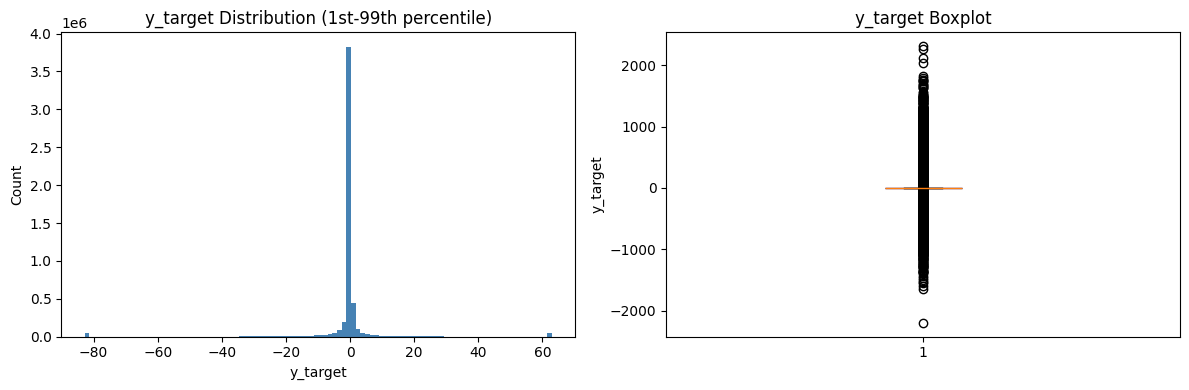

27

In [ ]:
target = train_df[TARGET_COL]

print("=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
print("Count:   ", target.count())
print("Mean:    ", round(target.mean(), 6))
print("Std Dev: ", round(target.std(), 6))
print("Min:     ", round(target.min(), 6))
print("25%:     ", round(target.quantile(0.25), 6))
print("Median:  ", round(target.median(), 6))
print("75%:     ", round(target.quantile(0.75), 6))
print("Max:     ", round(target.max(), 6))
print("Skewness:", round(target.skew(), 6))
print("Kurtosis:", round(target.kurt(), 6))

print("\n" + "=" * 50)
print("OUTLIER CHECK (values beyond 3 std devs)")
print("=" * 50)
mean, std = target.mean(), target.std()
outliers = ((target < mean - 3*std) | (target > mean + 3*std)).sum()
print(f"Outliers: {outliers} ({round(outliers/len(target)*100, 2)}% of rows)")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(target.clip(lower=target.quantile(0.01),
                          upper=target.quantile(0.99)), bins=100, color='steelblue', edgecolor='none')
axes[0].set_title("y_target Distribution (1st-99th percentile)")
axes[0].set_xlabel("y_target")
axes[0].set_ylabel("Count")

axes[1].boxplot(target.dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title("y_target Boxplot")
axes[1].set_ylabel("y_target")

plt.tight_layout()
plt.show()

# Clean up
del target
gc.collect()

+ Heavily concentrated near zero — the median is essentially 0 (-0.0006) and 50% of values fall between -0.13 and +0.05
+ Extreme outliers exist — min of -2,201 and max of +2,314, which explains the massive kurtosis of 289 (a normal distribution would be ~3)
+ Slightly right-skewed (skewness of 1.19) meaning there are more extreme positive outliers than negative
1.47% outliers beyond 3 standard deviations — not alarming but worth knowing
+ The boxplot visually confirms the target is essentially a tight band around zero with extreme tails

7. Explore the forecasting structure:

HORIZON DISTRIBUTION
horizon
1     1394653
3     1385816
10    1337236
25    1219709
Name: count, dtype: int64

TS_INDEX RANGE
Min ts_index: 1
Max ts_index: 3601
Unique ts_index values: 3601

ENTITY COUNTS
Unique codes:          23
Unique sub_codes:      180
Unique sub_categories: 5

ROWS PER HORIZON
horizon
1     1394653
3     1385816
10    1337236
25    1219709
dtype: int64


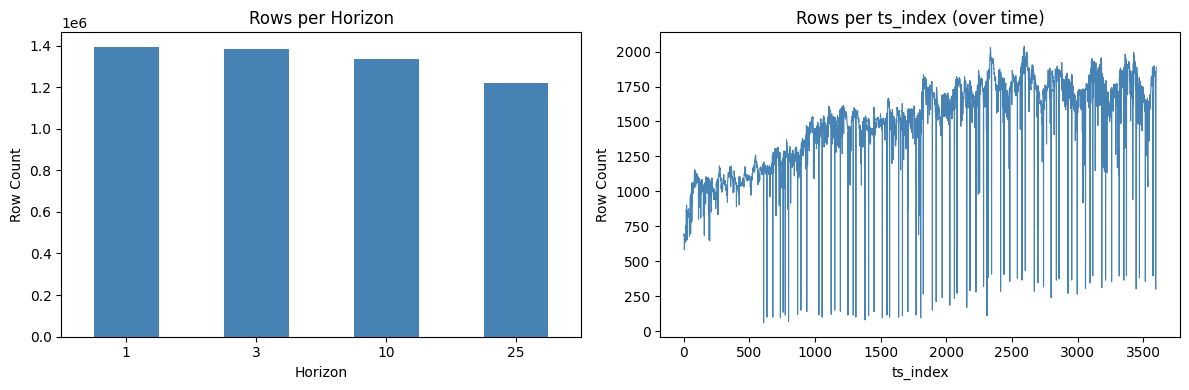

11080

In [ ]:
print("=" * 50)
print("HORIZON DISTRIBUTION")
print("=" * 50)
print(train_df[HORIZON_COL].value_counts().sort_index())

print("\n" + "=" * 50)
print("TS_INDEX RANGE")
print("=" * 50)
print("Min ts_index:", train_df[TIME_COL].min())
print("Max ts_index:", train_df[TIME_COL].max())
print("Unique ts_index values:", train_df[TIME_COL].nunique())

print("\n" + "=" * 50)
print("ENTITY COUNTS")
print("=" * 50)
print("Unique codes:         ", train_df["code"].nunique())
print("Unique sub_codes:     ", train_df["sub_code"].nunique())
print("Unique sub_categories:", train_df["sub_category"].nunique())

print("\n" + "=" * 50)
print("ROWS PER HORIZON")
print("=" * 50)
horizon_counts = train_df.groupby(HORIZON_COL).size()
print(horizon_counts)

# Plot rows per horizon
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

horizon_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("Rows per Horizon")
axes[0].set_xlabel("Horizon")
axes[0].set_ylabel("Row Count")
axes[0].tick_params(axis='x', rotation=0)

train_df.groupby(TIME_COL).size().plot(ax=axes[1], color="steelblue", linewidth=0.8)
axes[1].set_title("Rows per ts_index (over time)")
axes[1].set_xlabel("ts_index")
axes[1].set_ylabel("Row Count")

plt.tight_layout()
plt.show()

gc.collect()

+ 4 forecast horizons (1, 3, 10, 25) with fairly balanced row counts — horizon 1 has the most rows and horizon 25 the fewest, which makes sense since longer horizons have less historical data available
+ 3,601 time steps (ts_index 1 to 3601) — a long time series
+ Entity structure is manageable — only 23 unique codes, 180 sub_codes, and 5 sub_categories, meaning these can be effectively encoded as categorical features
+ The rows per ts_index plot shows the number of entities grows over time, with periodic dips (possibly missing periods) — this is important for our time-based split

8. Examine how y_target behaves over time:

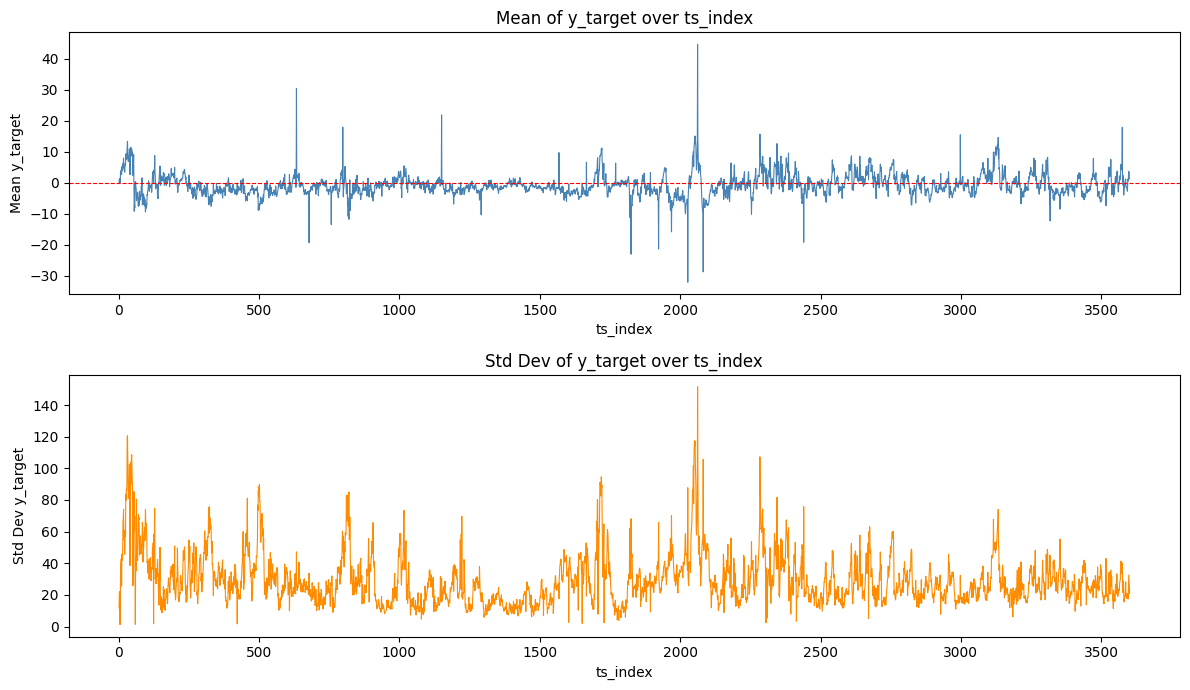

Mean y_target by horizon:
horizon
1    -0.0827
3    -0.2524
10   -0.7760
25   -1.6819
Name: y_target, dtype: float64


6684

In [ ]:
time_stats = train_df.groupby(TIME_COL)[TARGET_COL].agg(["mean", "std"]).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Mean of y_target over time
axes[0].plot(time_stats[TIME_COL], time_stats["mean"],
             color="steelblue", linewidth=0.8)
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0].set_title("Mean of y_target over ts_index")
axes[0].set_xlabel("ts_index")
axes[0].set_ylabel("Mean y_target")

# Std of y_target over time
axes[1].plot(time_stats[TIME_COL], time_stats["std"],
             color="darkorange", linewidth=0.8)
axes[1].set_title("Std Dev of y_target over ts_index")
axes[1].set_xlabel("ts_index")
axes[1].set_ylabel("Std Dev y_target")

plt.tight_layout()
plt.show()

# Also check mean y_target per horizon
print("Mean y_target by horizon:")
print(train_df.groupby(HORIZON_COL)[TARGET_COL].mean().round(4))

del time_stats
gc.collect()

+ Mean hovers around zero over time but with occasional sharp spikes — this confirms the target behaves like financial returns, mostly small with rare large moves
+ Volatility (std dev) is not constant — there are clear spikes at certain time periods (around ts_index 2000-2100 especially), which likely represent turbulent market periods
+ Very interesting horizon pattern — the mean y_target becomes increasingly negative as the horizon grows (from -0.08 at horizon 1 to -1.68 at horizon 25). This tells us that longer-horizon predictions tend to be more negative on average, which is a meaningful signal the model needs to learn
+ This confirms that horizon must be kept as a feature — it has a real relationship with the target

9.  Confirm which columns to keep and which to exclude:

In [ ]:
print("Columns EXCLUDED from features (non-predictive):")
print("  -", ID_COL,     "→ row identifier only")
print("  -", TARGET_COL, "→ outcome variable")
print("  -", WEIGHT_COL, "→ evaluation weight only")

print("\nColumns KEPT as features:")
print("  - horizon       → defines forecast lead time (keep!)")
print("  - ts_index      → time position (keep!)")
print("  - code          → entity grouping (keep!)")
print("  - sub_code      → entity grouping (keep!)")
print("  - sub_category  → entity grouping (keep!)")
print("  - feature_* columns → numeric predictors (keep!)")

print("\nFinal feature count:", len(FEATURE_COLS))
print("Features:", FEATURE_COLS[:5], "...", FEATURE_COLS[-5:])

Columns EXCLUDED from features (non-predictive):
  - id → row identifier only
  - y_target → outcome variable
  - weight → evaluation weight only

Columns KEPT as features:
  - horizon       → defines forecast lead time (keep!)
  - ts_index      → time position (keep!)
  - code          → entity grouping (keep!)
  - sub_code      → entity grouping (keep!)
  - sub_category  → entity grouping (keep!)
  - feature_* columns → numeric predictors (keep!)

Final feature count: 91
Features: ['code', 'sub_code', 'sub_category', 'horizon', 'ts_index'] ... ['feature_cd', 'feature_ce', 'feature_cf', 'feature_cg', 'feature_ch']


10. Convert categorical columns to correct dtype:

In [ ]:
CAT_COLS = ["code", "sub_code", "sub_category", "horizon"]

for col in CAT_COLS:
    train_df[col] = train_df[col].astype("category")
    test_df[col]  = test_df[col].astype("category")

print("Categorical columns converted:")
for col in CAT_COLS:
    print(f"  {col}: {train_df[col].nunique()} unique values")

print("\nMemory usage before vs after:")
print("Data types in train_df:")
print(train_df[CAT_COLS].dtypes)

gc.collect()

Categorical columns converted:
  code: 23 unique values
  sub_code: 180 unique values
  sub_category: 5 unique values
  horizon: 4 unique values

Memory usage before vs after:
Data types in train_df:
code            category
sub_code        category
sub_category    category
horizon         category
dtype: object


0

11. Median Imputation on missing values:

In [ ]:
def reduce_memory(df):
    for col in df.columns:
        col_type = df[col].dtype

        if col_type == "float64":
            df[col] = df[col].astype("float32")
        elif col_type == "int64":
            df[col] = df[col].astype("int32")

    return df

print("Reducing train_df memory...")
train_df = reduce_memory(train_df)
gc.collect()

print("Reducing test_df memory...")
test_df = reduce_memory(test_df)
gc.collect()

print("\nMemory usage after reduction:")
print(f"  train_df: {train_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"  test_df:  {test_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

print("\nData types remaining:")
print(train_df.dtypes.value_counts())

Reducing train_df memory...
